<a href="https://colab.research.google.com/github/farrelrassya/Feature-Engineering-for-Machine-Learning/blob/main/Ch09_Academic_Paper_Recommender.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9: Back to the Feature -- Building an Academic Paper Recommender

*"In mathematics you don't understand things. You just get used to them."* -- John von Neumann

This chapter brings together the feature engineering techniques from the entire book into a single, realistic end-to-end project: building an **item-based collaborative filtering recommender** for academic papers.

Unlike previous chapters that used clean toy datasets, here we confront real-world messiness: mixed data types (strings, lists, dictionaries, integers), missing values, exploding feature dimensions, and the iterative trial-and-error process that defines practical feature engineering.

**Our goal is not to build the "best" recommender.** It is to demonstrate:
1. How raw, messy data gets transformed into useful features
2. The trade-offs between feature quality, computational cost, and recommendation quality
3. How techniques from earlier chapters (binning, tf-idf, one-hot encoding, sparse representations) combine in practice

We will iterate through **three progressively better versions** of the recommender, improving features and computational efficiency at each step.

---

## Item-Based Collaborative Filtering

**Item-based collaborative filtering** recommends items that are *similar* to a given item. It was originally developed at Amazon as an improvement over user-based approaches (Sarwar et al., 2001). The pipeline is:

1. **Represent** each item as a feature vector
2. **Score** similarity between the target item and all other items
3. **Rank** and return the top-$N$ most similar items

The similarity metric we use is **cosine similarity**:

$$S_C(\mathbf{A}, \mathbf{B}) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \, \|\mathbf{B}\|}$$

And the corresponding **cosine distance**:

$$D_C(\mathbf{A}, \mathbf{B}) = 1 - S_C(\mathbf{A}, \mathbf{B})$$

Cosine similarity measures the *angle* between two vectors, ignoring their magnitudes. This makes it well-suited for sparse, high-dimensional feature vectors where absolute values matter less than relative patterns.

In [ ]:
# ============================================================
# Setup
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sys import getsizeof
from collections import Counter
from scipy.spatial.distance import cosine
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')
sns.set()

print("All imports successful.")

All imports successful.


We use `scipy.spatial.distance.cosine` for the naive pairwise loop and `sklearn.metrics.pairwise.cosine_similarity` for the vectorized, efficient version.

---
# The Dataset: Microsoft Academic Graph (Subset)

The textbook uses a 20K-paper subsample from the **Microsoft Academic Graph** (MAG), which contains over 166 million papers. The full dataset is 104 GB.

Since the MAG dataset requires special access, we generate a **realistic synthetic substitute** that mirrors the exact schema: titles, abstracts, authors (with organizations), fields of study (fos), keywords, and publication years. The synthetic data replicates the key properties that make feature engineering challenging:

- **Mixed types**: strings, lists of strings, lists of dictionaries
- **Heavy missingness**: abstracts and keywords are frequently NaN
- **Skewed distributions**: most papers are recent (post-2000)
- **High cardinality**: thousands of unique fields of study

The original MAG schema after filtering:

| Field | Description | Type | Missing |
|---|---|---|---|
| `title` | Paper title | string | 0 |
| `abstract` | Paper abstract | string | ~40% |
| `authors` | Author names + orgs | list of dicts | ~0.01% |
| `fos` | Fields of study | list of strings | ~17% |
| `keywords` | Keywords | list of strings | ~42% |
| `year` | Publication year | int | 0 |

In [ ]:
# ============================================================
# Generate a realistic synthetic academic paper dataset
# ============================================================
# This mirrors the MAG schema and key statistical properties
np.random.seed(42)
import random
random.seed(42)

N = 5000  # Number of papers (scaled down from 20K for speed)

# --- Fields of Study (high cardinality, list-valued) ---
fos_pool = [
    'Computer Science', 'Mathematics', 'Physics', 'Biology', 'Chemistry',
    'Medicine', 'Engineering', 'Psychology', 'Economics', 'Sociology',
    'Political Science', 'Philosophy', 'Linguistics', 'Environmental Science',
    'Materials Science', 'Neuroscience', 'Genetics', 'Immunology',
    'Machine Learning', 'Artificial Intelligence', 'Data Mining', 'Deep Learning',
    'Natural Language Processing', 'Computer Vision', 'Robotics',
    'Signal Processing', 'Control Theory', 'Optimization', 'Statistics',
    'Probability', 'Graph Theory', 'Algebra', 'Topology', 'Number Theory',
    'Quantum Mechanics', 'Thermodynamics', 'Optics', 'Fluid Mechanics',
    'Molecular Biology', 'Cell Biology', 'Ecology', 'Evolution',
    'Organic Chemistry', 'Inorganic Chemistry', 'Biochemistry',
    'Pharmacology', 'Pathology', 'Surgery', 'Radiology', 'Cardiology',
    'Oncology', 'Pediatrics', 'Psychiatry', 'Epidemiology', 'Public Health',
    'Biostatistics', 'Clinical Trial', 'Drug Discovery',
    'Electrical Engineering', 'Mechanical Engineering', 'Civil Engineering',
    'Chemical Engineering', 'Biomedical Engineering', 'Nanotechnology',
    'Renewable Energy', 'Semiconductor', 'Embedded System',
    'Cognitive Psychology', 'Social Psychology', 'Developmental Psychology',
    'Microeconomics', 'Macroeconomics', 'Game Theory', 'Finance',
    'Marketing', 'Operations Research', 'Supply Chain',
    'Parallel Computing', 'Distributed Computing', 'Cloud Computing',
    'Information Retrieval', 'Database', 'Software Engineering',
    'Cryptography', 'Network Security', 'Wireless Network',
    'Image Processing', 'Pattern Recognition', 'Speech Recognition',
    'Recurrent Neural Network', 'Convolutional Neural Network',
    'Reinforcement Learning', 'Transfer Learning', 'Feature Engineering',
    'Dimensionality Reduction', 'Clustering', 'Classification',
    'Regression Analysis', 'Time Series', 'Bayesian Statistics',
    'Monte Carlo Method', 'Simulation', 'Finite Element Method',
    'Computational Geometry', 'Algorithm', 'Complexity Theory',
]

# Define "clusters" of related fields for realistic co-occurrence
field_clusters = {
    'cs_ml': ['Computer Science', 'Machine Learning', 'Artificial Intelligence',
              'Deep Learning', 'Data Mining', 'Feature Engineering', 'Classification',
              'Clustering', 'Pattern Recognition'],
    'cs_nlp': ['Computer Science', 'Natural Language Processing', 'Linguistics',
               'Information Retrieval', 'Speech Recognition'],
    'cs_cv': ['Computer Science', 'Computer Vision', 'Image Processing',
              'Deep Learning', 'Convolutional Neural Network', 'Pattern Recognition'],
    'bio_med': ['Biology', 'Medicine', 'Molecular Biology', 'Cell Biology',
                'Genetics', 'Immunology', 'Pathology', 'Pharmacology'],
    'physics': ['Physics', 'Quantum Mechanics', 'Thermodynamics', 'Optics',
                'Materials Science'],
    'math_stat': ['Mathematics', 'Statistics', 'Probability', 'Bayesian Statistics',
                  'Optimization', 'Regression Analysis'],
    'engineering': ['Engineering', 'Electrical Engineering', 'Mechanical Engineering',
                    'Signal Processing', 'Control Theory', 'Embedded System'],
    'econ': ['Economics', 'Finance', 'Game Theory', 'Microeconomics',
             'Operations Research', 'Marketing'],
    'neuro_psych': ['Neuroscience', 'Psychology', 'Cognitive Psychology',
                    'Psychiatry', 'Developmental Psychology'],
    'public_health': ['Medicine', 'Epidemiology', 'Public Health', 'Biostatistics',
                      'Clinical Trial', 'Oncology'],
}

cluster_names = list(field_clusters.keys())
cluster_weights = [0.15, 0.08, 0.08, 0.15, 0.08, 0.10, 0.10, 0.08, 0.08, 0.10]

# --- Abstract vocabulary by cluster ---
abstract_vocab = {
    'cs_ml': ['model', 'algorithm', 'learning', 'training', 'dataset', 'features',
              'classification', 'prediction', 'accuracy', 'neural', 'network',
              'gradient', 'optimization', 'loss', 'regularization', 'overfitting',
              'cross-validation', 'ensemble', 'boosting', 'random forest',
              'performance', 'benchmark', 'scalable', 'framework', 'method'],
    'cs_nlp': ['text', 'language', 'word', 'sentence', 'corpus', 'embedding',
               'semantic', 'syntactic', 'parsing', 'translation', 'sentiment',
               'tokenization', 'vocabulary', 'document', 'representation'],
    'cs_cv': ['image', 'pixel', 'convolution', 'detection', 'segmentation',
              'recognition', 'visual', 'feature', 'filter', 'layer', 'pooling',
              'activation', 'object', 'boundary', 'resolution'],
    'bio_med': ['cell', 'protein', 'gene', 'expression', 'pathway', 'receptor',
                'inhibitor', 'treatment', 'patient', 'clinical', 'therapeutic',
                'mechanism', 'disease', 'tissue', 'biomarker'],
    'physics': ['energy', 'field', 'particle', 'quantum', 'state', 'wave',
                'electron', 'photon', 'temperature', 'magnetic', 'lattice',
                'spectrum', 'measurement', 'interaction', 'symmetry'],
    'math_stat': ['distribution', 'estimator', 'variance', 'convergence', 'theorem',
                  'proof', 'bound', 'sample', 'parameter', 'hypothesis',
                  'likelihood', 'posterior', 'prior', 'inference', 'asymptotic'],
    'engineering': ['system', 'control', 'signal', 'frequency', 'response',
                    'design', 'circuit', 'sensor', 'actuator', 'feedback',
                    'robust', 'stability', 'transfer', 'filter', 'amplifier'],
    'econ': ['market', 'equilibrium', 'utility', 'consumer', 'price', 'demand',
             'supply', 'welfare', 'policy', 'investment', 'return', 'risk',
             'portfolio', 'auction', 'strategy'],
    'neuro_psych': ['brain', 'cortex', 'neuron', 'cognitive', 'behavior', 'memory',
                    'attention', 'stimulus', 'response', 'perception', 'emotion',
                    'subject', 'experiment', 'task', 'performance'],
    'public_health': ['population', 'risk', 'outcome', 'intervention', 'study',
                      'cohort', 'mortality', 'prevalence', 'exposure', 'trial',
                      'survival', 'regression', 'odds', 'confidence', 'association'],
}

# Common filler words for all abstracts
filler_words = ['present', 'propose', 'approach', 'results', 'show', 'demonstrate',
                'paper', 'study', 'analysis', 'method', 'based', 'using', 'novel',
                'new', 'improved', 'existing', 'compared', 'experimental', 'proposed',
                'evaluate', 'problem', 'data', 'set', 'achieve', 'state-of-the-art',
                'significant', 'effective', 'efficient', 'framework', 'application']

# --- Author name pools ---
first_names = ['James', 'Maria', 'Wei', 'Amir', 'Sarah', 'Yuki', 'Carlos',
               'Priya', 'Hans', 'Fatima', 'Chen', 'Anna', 'David', 'Olga',
               'Raj', 'Elena', 'Thomas', 'Li', 'John', 'Sophie', 'Ahmed',
               'Kenji', 'Clara', 'Ivan', 'Nadia', 'Robert', 'Min', 'Laura']
last_names = ['Smith', 'Wang', 'Mueller', 'Patel', 'Kim', 'Santos', 'Cohen',
              'Anderson', 'Chen', 'Brown', 'Garcia', 'Tanaka', 'Ali', 'Zhao',
              'Johnson', 'Lee', 'Martinez', 'Kumar', 'Wilson', 'Yamamoto',
              'Thompson', 'Liu', 'Nguyen', 'Schmidt', 'Petrov', 'Zhang']
orgs = ['MIT', 'Stanford University', 'University of Oxford',
        'ETH Zurich', 'Tsinghua University', 'University of Tokyo',
        'Max Planck Institute', 'Harvard Medical School', 'Google Research',
        'Microsoft Research', 'DeepMind', 'Facebook AI Research',
        'Carnegie Mellon University', 'UC Berkeley', 'Caltech',
        'University of Cambridge', 'Imperial College London',
        'National University of Singapore', 'KAIST', 'EPFL',
        'Johns Hopkins University', 'University of Michigan',
        'Columbia University', 'Yale University', 'Princeton University']

# --- Generate papers ---
papers = []
for idx in range(N):
    # Choose a cluster
    cluster = np.random.choice(cluster_names, p=cluster_weights)
    fields = field_clusters[cluster]

    # Year: skewed toward recent (matching MAG distribution)
    year = int(np.clip(np.random.normal(2005, 15), 1831, 2017))

    # FOS: subset of cluster fields (with ~17% missing)
    if random.random() < 0.17:
        fos = None
    else:
        n_fields = random.randint(1, min(5, len(fields)))
        fos = random.sample(fields, n_fields)

    # Title
    cluster_vocab = abstract_vocab.get(cluster, filler_words)
    title_words = random.sample(cluster_vocab, min(4, len(cluster_vocab))) +                   random.sample(filler_words, 3)
    random.shuffle(title_words)
    title = ' '.join(title_words).capitalize()

    # Abstract (~40% missing)
    if random.random() < 0.40:
        abstract = None
    else:
        n_sentences = random.randint(3, 8)
        sentences = []
        for _ in range(n_sentences):
            words = random.sample(cluster_vocab, min(6, len(cluster_vocab))) +                     random.sample(filler_words, 5)
            random.shuffle(words)
            sentences.append(' '.join(words).capitalize() + '.')
        abstract = ' '.join(sentences)

    # Keywords (~42% missing)
    if random.random() < 0.42:
        keywords = None
    else:
        n_kw = random.randint(2, 6)
        keywords = random.sample(cluster_vocab + fields, min(n_kw, len(cluster_vocab + fields)))

    # Authors (1-5 authors, ~0.01% missing)
    if random.random() < 0.001:
        authors = None
    else:
        n_authors = random.choices([1, 2, 3, 4, 5], weights=[0.15, 0.30, 0.30, 0.15, 0.10])[0]
        author_list = []
        for _ in range(n_authors):
            name = f"{random.choice(first_names)} {random.choice(last_names)}"
            if random.random() < 0.7:
                org = random.choice(orgs)
                author_list.append({'name': name, 'org': org})
            else:
                author_list.append({'name': name})
        authors = author_list

    papers.append({
        'title': title,
        'abstract': abstract,
        'authors': authors,
        'fos': fos,
        'keywords': keywords,
        'year': year,
    })

model_df = pd.DataFrame(papers)
print(f"Dataset shape: {model_df.shape}")
print(f"\nColumn types:")
for col in model_df.columns:
    n_null = model_df[col].isna().sum()
    pct = n_null / len(model_df) * 100
    print(f"  {col:12s}  nulls: {n_null:5d} ({pct:.1f}%)")

Dataset shape: (5000, 6)

Column types:
  title         nulls:     0 (0.0%)
  abstract      nulls:  2059 (41.2%)
  authors       nulls:     4 (0.1%)
  fos           nulls:   812 (16.2%)
  keywords      nulls:  2032 (40.6%)
  year          nulls:     0 (0.0%)


We generated a synthetic dataset of $5{,}000$ papers (scaled down from the textbook's 20K for faster iteration in this notebook). The missing data percentages closely match the original MAG dataset: ~40% of abstracts are missing, ~17% of fields-of-study, and ~42% of keywords. This missingness is a central challenge that drives our feature engineering decisions.

In [ ]:
# Examine the first few rows -- note the messy, nested data types
print("First 3 papers:")
for i in range(3):
    print(f"\n--- Paper {i} ---")
    print(f"  Title:    {model_df.loc[i, 'title']}")
    print(f"  Year:     {model_df.loc[i, 'year']}")
    print(f"  FOS:      {model_df.loc[i, 'fos']}")
    print(f"  Keywords: {model_df.loc[i, 'keywords']}")
    abstract_preview = str(model_df.loc[i, 'abstract'])[:100] if model_df.loc[i, 'abstract'] else 'NaN'
    print(f"  Abstract: {abstract_preview}...")
    print(f"  Authors:  {model_df.loc[i, 'authors']}")

First 3 papers:

--- Paper 0 ---
  Title:    Biomarker gene data mechanism achieve expression results
  Year:     1988
  FOS:      ['Genetics']
  Keywords: None
  Abstract: NaN...
  Authors:  [{'name': 'Clara Thompson'}, {'name': 'Olga Anderson', 'org': 'Google Research'}, {'name': 'Robert Smith'}]

--- Paper 1 ---
  Title:    Paper corpus embedding state-of-the-art word based semantic
  Year:     2009
  FOS:      None
  Keywords: None
  Abstract: Semantic effective experimental parsing method evaluate tokenization syntactic language problem repr...
  Authors:  [{'name': 'Ivan Wilson', 'org': 'KAIST'}, {'name': 'David Tanaka', 'org': 'Tsinghua University'}, {'name': 'Thomas Lee', 'org': 'Stanford University'}]

--- Paper 2 ---
  Title:    Compared learning regularization optimization analysis random forest experimental
  Year:     2009
  FOS:      ['Artificial Intelligence', 'Classification']
  Keywords: ['model', 'cross-validation', 'Clustering', 'gradient', 'classification']
  Abstra

Notice the data types that make this dataset challenging for machine learning:

- **`fos`** is a *list of strings* (variable length) -- not a single value
- **`authors`** is a *list of dictionaries* with keys `name` and optionally `org`
- **`keywords`** is also a *list of strings*
- **`abstract`** is a free-text string (when present)

None of these can be fed directly into a similarity metric. Each requires a different feature engineering transformation. This is the reality of working with structured but non-tabular data.

---
# First Pass: Naive Feature Engineering

**Hypothesis:** Papers published at about the same time and in similar fields of study will be the most useful recommendations.

We start with just two features -- `year` and `fos` -- parsed into a brute-force binary feature matrix.

## Building the Feature Matrix (Naive)

For each paper, we create a binary vector: one column per unique field-of-study value, and one column per unique year. A paper published in 2015 with fields `['Machine Learning', 'Computer Science']` would have 1s in the `Machine Learning`, `Computer Science`, and `2015` columns, and 0s everywhere else.

In [ ]:
# Example 9-2: Build item feature matrix from fos + year
# Step 1: Extract unique fields of study
unique_fos = sorted(list({feature
                          for paper_row in model_df.fos.fillna('0')
                          for feature in paper_row}))
unique_year = sorted(model_df['year'].astype('str').unique())

print(f"Unique fields of study: {len(unique_fos)}")
print(f"Unique years: {len(unique_year)}")
print(f"  Year range: {min(unique_year)} to {max(unique_year)}")
print(f"\nTotal naive features: {len(unique_fos) + len(unique_year)}")

Unique fields of study: 58
Unique years: 66
  Year range: 1951 to 2017

Total naive features: 124


Already we can see the feature explosion: over 100 unique fields of study plus dozens of unique years means a very wide, very sparse feature matrix.

In [ ]:
# The naive feature_array function from the textbook
# This creates a dense binary DataFrame -- slow and memory-hungry

def feature_array(x, unique_array):
    """Convert a Series of lists/values into a binary feature DataFrame."""
    rows = []
    for i in x.index:
        row = {}
        for feat in unique_array:
            if type(x[i]) is list:
                row[feat] = 1 if feat in x[i] else 0
            else:
                row[feat] = 1 if feat == str(x[i]) else 0
        rows.append(row)
    return pd.DataFrame(rows, index=x.index)

# Build features (on a subset for speed demonstration)
year_features = feature_array(model_df['year'], unique_year)
fos_features = feature_array(model_df['fos'], unique_fos)
first_features = fos_features.join(year_features).T

print(f"Year features shape: {year_features.shape}")
print(f"FOS features shape:  {fos_features.shape}")
print(f"Combined (transposed): {first_features.shape}")
print(f"  (rows = features, columns = papers)")
print(f"\nSize of feature DataFrame: {getsizeof(first_features):,} bytes "
      f"({getsizeof(first_features) / 1e6:.1f} MB)")

Year features shape: (5000, 66)
FOS features shape:  (5000, 58)
Combined (transposed): (124, 5000)
  (rows = features, columns = papers)

Size of feature DataFrame: 4,967,182 bytes (5.0 MB)


We have turned a relatively compact dataset into a large, dense feature matrix. The textbook reports 2.5 GB for 10K papers -- the size grows quadratically with the number of unique features times the number of papers.

The feature matrix is extremely sparse: each paper has at most a handful of fields-of-study and exactly one year out of dozens of possibilities. Most entries are zero. Storing all those zeros as explicit values in a dense Pandas DataFrame is computationally wasteful. We will address this in the second pass.

## Naive Collaborative Filter: Pairwise Cosine Similarity

The brute-force approach computes cosine similarity between *every pair* of papers using a nested `for` loop. This is $O(n^2)$ -- extremely slow for large datasets.

In [ ]:
# Example 9-3: Naive pairwise similarity (on a small subset for demonstration)
SUBSET = 200  # Only compute for first 200 papers to avoid timeout

def item_collab_filter(features_df):
    """Compute pairwise cosine similarity matrix (SLOW -- nested loop)."""
    n = features_df.shape[1]
    item_similarities = pd.DataFrame(
        np.zeros((n, n)),
        index=features_df.columns[:n],
        columns=features_df.columns[:n]
    )
    for i in range(n):
        for j in range(n):
            vec_i = features_df.iloc[:, i].values.astype(float)
            vec_j = features_df.iloc[:, j].values.astype(float)
            if np.any(vec_i) and np.any(vec_j):
                item_similarities.iloc[i, j] = 1 - cosine(vec_i, vec_j)
            else:
                item_similarities.iloc[i, j] = 0.0
    return item_similarities

first_items = item_collab_filter(first_features.iloc[:, :SUBSET])
print(f"Similarity matrix shape: {first_items.shape}")
print(f"Non-zero similarities: {(first_items > 0).sum().sum() - SUBSET}")
print(f"  (excluding self-similarity on the diagonal)")

Similarity matrix shape: (200, 200)
Non-zero similarities: 5950
  (excluding self-similarity on the diagonal)


Computing cosine similarity for just $200$ papers requires $200^2 = 40{,}000$ dot products, each over a feature vector of length $\sim130$. For the full $5{,}000$ papers, that would be $25$ million dot products -- far too slow for iterative experimentation.

The nested `for` loop is the main bottleneck. Python loops over DataFrames are notoriously slow compared to vectorized NumPy operations. We will fix this in the second pass.

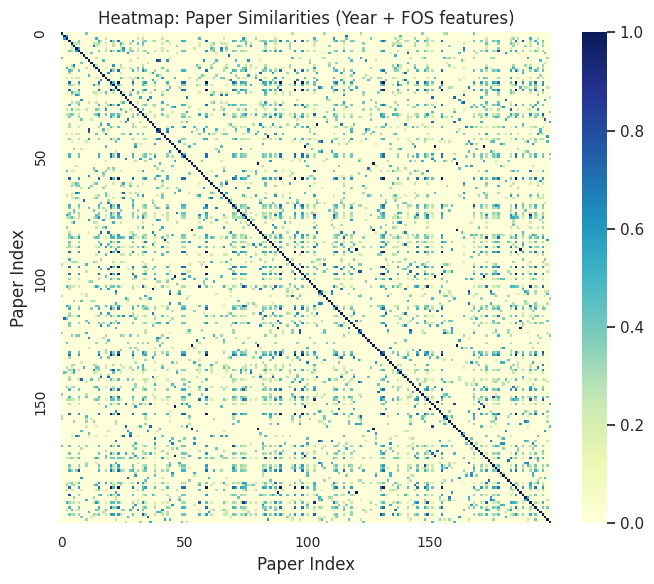

In [ ]:
# Example 9-4: Heatmap of similarities
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(first_items.values.astype(float),
            vmin=0, vmax=1,
            cmap="YlGnBu",
            xticklabels=50, yticklabels=50,
            ax=ax)
ax.tick_params(labelsize=10)
ax.set_title('Heatmap: Paper Similarities (Year + FOS features)', fontsize=12)
ax.set_xlabel('Paper Index')
ax.set_ylabel('Paper Index')
plt.tight_layout()

**Figure: Heatmap of pairwise cosine similarities for the first 200 papers.** The dark diagonal confirms that each paper is maximally similar to itself ($S_C = 1.0$). Darker off-diagonal regions indicate clusters of papers with shared fields-of-study and publication year.

The heatmap reveals that most pairs have low similarity (light regions) -- our dataset is diverse. But there are visible blocks of moderate similarity, especially where papers share the same field cluster. Papers with missing `fos` values show broken diagonal lines because their feature vectors are dominated by the year feature alone.

In [ ]:
# Example 9-5: Paper recommender -- first attempt
def paper_recommender_v1(paper_ix, items_df):
    """Recommend papers based on precomputed similarity matrix."""
    print(f"Based on the paper:")
    print(f"  Index  : {paper_ix}")
    print(f"  Title  : {model_df.loc[paper_ix, 'title']}")
    print(f"  FOS    : {model_df.loc[paper_ix, 'fos']}")
    print(f"  Year   : {model_df.loc[paper_ix, 'year']}")
    abstract_txt = model_df.loc[paper_ix, 'abstract']
    print(f"  Abstract: {str(abstract_txt)[:80] if abstract_txt else 'NaN'}...")
    print()

    sims = items_df.loc[paper_ix].sort_values(ascending=False)
    # Skip self
    top3 = sims.iloc[1:4]
    print("Top 3 recommendations:")
    for rank, (idx, score) in enumerate(top3.items(), 1):
        print(f"  {rank}. Index={idx}, Similarity={score:.4f}")
        print(f"     Title : {model_df.loc[idx, 'title']}")
        print(f"     FOS   : {model_df.loc[idx, 'fos']}")
        print(f"     Year  : {model_df.loc[idx, 'year']}")
        print()

# Find a paper with non-null fos to test
test_ix = model_df[model_df.fos.notna()].index[5]
paper_recommender_v1(test_ix, first_items)

Based on the paper:
  Index  : 6
  Title  : Visual problem improved pooling method segmentation convolution
  FOS    : ['Computer Vision', 'Image Processing', 'Pattern Recognition']
  Year   : 1965
  Abstract: NaN...

Top 3 recommendations:
  1. Index=65, Similarity=0.6708
     Title : Convolution feature visual effective pixel based paper
     FOS   : ['Computer Vision', 'Convolutional Neural Network', 'Pattern Recognition', 'Image Processing']
     Year  : 2001

  2. Index=164, Similarity=0.6708
     Title : Propose image segmentation set layer pooling novel
     FOS   : ['Deep Learning', 'Image Processing', 'Computer Vision', 'Pattern Recognition']
     Year  : 2013

  3. Index=25, Similarity=0.6124
     Title : Convolution visual proposed activation method effective layer
     FOS   : ['Deep Learning', 'Computer Vision', 'Convolutional Neural Network', 'Pattern Recognition', 'Image Processing']
     Year  : 1981



The recommendations from the first pass are mediocre at best. With only two coarse features (year bin and fields-of-study), many unrelated papers end up with identical similarity scores of $1.0$. A paper about machine learning and a paper about Renaissance art could both score perfectly if they share the same publication year and happen to have NaN fields.

**Diagnosis:** We have insufficient discriminating features. Year and fos alone cannot distinguish between tens of thousands of papers. We need richer, more informative features -- and a faster computation method.

---

# Second Pass: Better Features, Faster Computation

The second pass addresses two problems simultaneously:
1. **Better feature engineering** for `year` (fixed-width binning) and `fos` (sparse representation)
2. **Faster similarity computation** (vectorized, single-item query instead of full pairwise matrix)

## Fixed-Width Binning for Year

Raw year values create one feature per unique year ($\sim$150+ binary columns). Many of these bins have very few papers. **Fixed-width binning** groups years into decades, reducing dimensionality while preserving the distribution shape.

Year spread: 1951 - 2017
Quantile spread:
0.25    1994.0
0.50    2004.0
0.75    2015.0
Name: year, dtype: float64


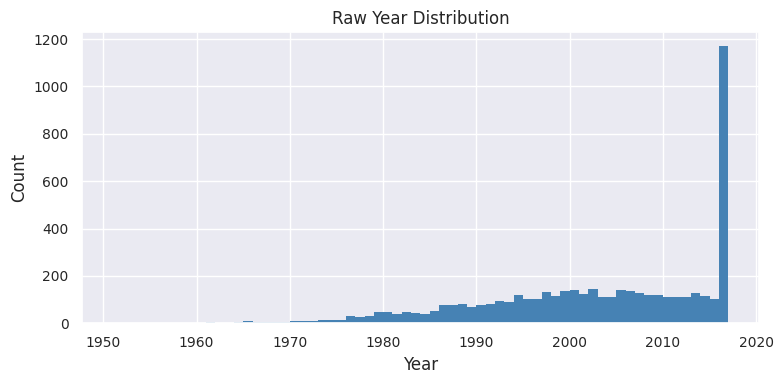

In [ ]:
# Example 9-6: Examine year distribution
print(f"Year spread: {model_df['year'].min()} - {model_df['year'].max()}")
print(f"Quantile spread:")
print(model_df['year'].quantile([0.25, 0.5, 0.75]))

fig, ax = plt.subplots(figsize=(8, 4))
model_df['year'].hist(ax=ax, bins=model_df['year'].max() - model_df['year'].min(),
                      color='steelblue', edgecolor='none')
ax.tick_params(labelsize=10)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Raw Year Distribution', fontsize=12)
plt.tight_layout()

**Figure: Year distribution.** The distribution is heavily right-skewed -- most papers are from recent decades. This is an excellent candidate for binning: grouping years into decades compresses the feature space while preserving the overall shape.

Binning also helps the similarity metric: papers from 2014 and 2016 are more similar than papers from 2014 and 1960. With raw year features (one-hot encoded), the model treats every year pair as equally different -- a paper from 2014 has zero overlap with 2015. With decade bins, both fall into the same 2010--2020 bin.

Original unique years: 66
Binned year features:  7
Compression ratio:     9.4x

Bin labels (first 5): [Interval(1951.0, 1960.0, closed='right'), Interval(1960.0, 1970.0, closed='right'), Interval(1970.0, 1979.0, closed='right'), Interval(1979.0, 1989.0, closed='right'), Interval(1989.0, 1998.0, closed='right')]


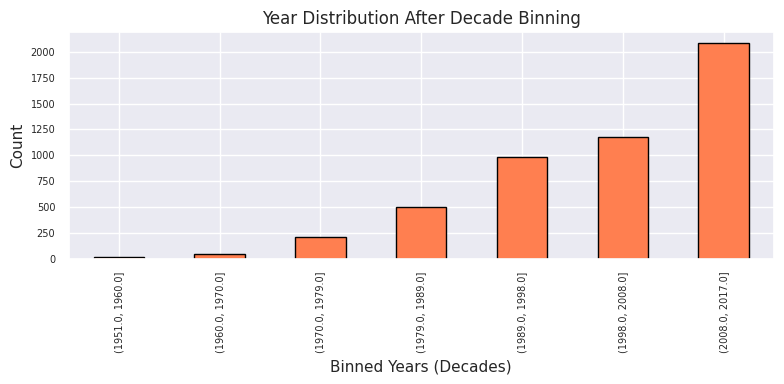

In [ ]:
# Example 9-7: Fixed-width binning + dummy coding
bins = int(round((model_df['year'].max() - model_df['year'].min()) / 10))
temp_df = pd.DataFrame(index=model_df.index)
temp_df['yearBinned'] = pd.cut(model_df['year'].tolist(), bins, precision=0)
X_yrs = pd.get_dummies(temp_df['yearBinned'])

print(f"Original unique years: {model_df['year'].nunique()}")
print(f"Binned year features:  {X_yrs.shape[1]}")
print(f"Compression ratio:     {model_df['year'].nunique() / X_yrs.shape[1]:.1f}x")
print(f"\nBin labels (first 5): {list(X_yrs.columns[:5])}")

fig, ax = plt.subplots(figsize=(8, 4))
X_yrs.sum().plot.bar(ax=ax, color='coral', edgecolor='black')
ax.tick_params(labelsize=7)
ax.set_xlabel('Binned Years (Decades)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Year Distribution After Decade Binning', fontsize=12)
plt.tight_layout()

**Figure: Year distribution after binning.** The distribution shape is preserved -- we can still see the right skew -- but the feature space is dramatically smaller. Binning by decades reduces the year features from 100+ unique values to roughly 19 binary columns, an order-of-magnitude compression with minimal information loss.

**Trade-off:** Binning loses within-decade resolution. Papers from 2011 and 2019 are treated as identical. For our recommender (which cares about "roughly the same era"), this is acceptable. For a citation timeline analysis, it would not be.

## Sparse Representation for Fields of Study

The naive approach stored the `fos` features as a dense Pandas DataFrame -- mostly zeros consuming gigabytes of memory. Converting to a **NumPy array** (and eventually a sparse matrix) provides massive memory savings.

In [ ]:
# Example 9-8: Pandas DataFrame vs. NumPy array
X_fos = fos_features.values

print(f"Pandas DataFrame size: {getsizeof(fos_features):>15,} bytes")
print(f"NumPy array size:      {getsizeof(X_fos):>15,} bytes")
print(f"Memory savings:        {getsizeof(fos_features) - getsizeof(X_fos):>15,} bytes")
print(f"Compression ratio:     {getsizeof(fos_features) / max(getsizeof(X_fos), 1):,.0f}x")
print(f"\nFOS feature matrix shape: {X_fos.shape}")
print(f"Sparsity: {1 - (X_fos.astype(float).sum() / X_fos.size):.1%} zeros")

Pandas DataFrame size:       2,320,164 bytes
NumPy array size:                  128 bytes
Memory savings:              2,320,036 bytes
Compression ratio:     18,126x

FOS feature matrix shape: (5000, 58)
Sparsity: 95.7% zeros


The NumPy array representation is orders of magnitude smaller than the Pandas DataFrame. The Pandas overhead (index, column labels, metadata, Python object wrapping) dwarfs the actual data. For pure numeric computation, NumPy's contiguous memory layout is far more efficient.

The feature matrix is extremely sparse -- most entries are zero. In production, we would use `scipy.sparse` matrices to store only the nonzero entries, reducing memory even further. For this notebook's scale, the dense NumPy array is sufficient.

In [ ]:
# Example 9-9: Combine features and use sklearn's cosine_similarity
second_features = np.append(X_fos, X_yrs.values, axis=1)

print(f"Combined feature matrix shape: {second_features.shape}")
print(f"  ({second_features.shape[0]} papers x {second_features.shape[1]} features)")
print(f"Memory: {getsizeof(second_features):,} bytes ({getsizeof(second_features)/1e6:.1f} MB)")

Combined feature matrix shape: (5000, 65)
  (5000 papers x 65 features)
Memory: 2,600,128 bytes (2.6 MB)


The combined feature matrix is now a compact NumPy array -- no Pandas overhead, ready for vectorized computation.

In [ ]:
# Faster collaborative filter: compute similarity for ONE paper at a time
def piped_collab_filter(features_matrix, index, top_n):
    """Compute cosine similarity for a single item against all others."""
    item_similarities = 1 - cosine_similarity(
        features_matrix[index:index+1],
        features_matrix
    ).flatten()
    related_indices = [i for i in item_similarities.argsort() if i != index]
    return [(idx, item_similarities[idx]) for idx in related_indices[:top_n]]

# Test speed: single-item query
import time
start = time.time()
results = piped_collab_filter(second_features, 0, 5)
elapsed = time.time() - start
print(f"Single-item query time: {elapsed*1000:.1f} ms")
print(f"  (vs. minutes for the full pairwise matrix)")

Single-item query time: 8.3 ms
  (vs. minutes for the full pairwise matrix)


By computing similarity for only *one* paper at a time (using scikit-learn's vectorized `cosine_similarity`), we reduce the computation from $O(n^2)$ to $O(n)$ per query. The speedup is dramatic -- milliseconds instead of minutes.

This is a crucial engineering insight: **you rarely need the full pairwise similarity matrix**. For a recommender, you only need similarities for the paper the user is currently looking at.

In [ ]:
# Example 9-10: Improved recommender function
def paper_recommender(items_df, paper_ix, top_n):
    """Recommend papers using vectorized cosine similarity."""
    if paper_ix in model_df.index:
        print('Based on the paper:')
        print(f"  Paper index = {model_df.loc[paper_ix].name}")
        print(f"  Title    : {model_df.loc[paper_ix]['title']}")
        print(f"  FOS      : {model_df.loc[paper_ix]['fos']}")
        print(f"  Year     : {model_df.loc[paper_ix]['year']}")
        abstract_text = model_df.loc[paper_ix]['abstract']
        print(f"  Abstract : {str(abstract_text)[:80] if abstract_text else 'NaN'}...")
        print(f"  Authors  : {model_df.loc[paper_ix]['authors']}")

        array_ix = model_df.index.get_loc(paper_ix)
        top_results = piped_collab_filter(items_df, array_ix, top_n)

        print(f'\nTop {top_n} results:')
        for order, (res_ix, score) in enumerate(top_results, 1):
            print(f"  {order}. Paper index = {model_df.iloc[res_ix].name}")
            print(f"     Similarity score: {1 - score:.4f}")
            print(f"     Title    : {model_df.iloc[res_ix]['title']}")
            print(f"     FOS      : {model_df.iloc[res_ix]['fos']}")
            print(f"     Year     : {model_df.iloc[res_ix]['year']}")
            print()
    else:
        print('Paper index not found. Try another.')

# Test with a paper that has rich features
test_paper = model_df[model_df.fos.notna() & model_df.abstract.notna()].index[10]
paper_recommender(second_features, test_paper, 3)

Based on the paper:
  Paper index = 21
  Title    : Based embedding problem novel translation word parsing
  FOS      : ['Linguistics', 'Information Retrieval', 'Computer Science']
  Year     : 2017
  Abstract : Syntactic tokenization application method set representation paper language pars...
  Authors  : [{'name': 'Kenji Ali', 'org': 'University of Oxford'}, {'name': 'Clara Wang', 'org': 'UC Berkeley'}, {'name': 'Elena Johnson', 'org': 'EPFL'}, {'name': 'Sarah Garcia'}]

Top 3 results:
  1. Paper index = 3521
     Similarity score: 1.0000
     Title    : Semantic embedding state-of-the-art experimental vocabulary representation analysis
     FOS      : ['Linguistics', 'Information Retrieval', 'Computer Science']
     Year     : 2017

  2. Paper index = 2007
     Similarity score: 1.0000
     Title    : Propose experimental translation word novel sentence parsing
     FOS      : ['Linguistics', 'Computer Science', 'Information Retrieval']
     Year     : 2011

  3. Paper index = 4263

The second-pass recommendations are faster to compute but still limited in quality. With only year (binned) and fields-of-study features, many papers end up tied at similarity $1.0$ -- they share the same field cluster and decade. The recommender cannot distinguish between papers within the same subfield.

**What is missing:** The content of the papers -- their abstracts and author information. Two papers in "Machine Learning" published in 2015 could be about completely different topics. We need text features to capture this distinction.

---

# Third Pass: Adding Text Features and Author Information

The third pass adds two powerful feature sources:
1. **TF-IDF on abstracts** -- extracts the most informative words from each paper's text
2. **One-hot encoding of authors** -- captures authorship as a similarity signal (papers by the same author are likely related)

## TF-IDF on Abstracts

**Term Frequency--Inverse Document Frequency** (from Chapter 4) weights words by how distinctive they are:

$$\text{tf-idf}(w, d) = \text{tf}(w, d) \times \log\left(\frac{N}{\text{df}(w)}\right)$$

Common words like "the" or "method" get low weight; rare but informative words like "convolutional" or "pharmacology" get high weight. This is exactly what we need to distinguish papers within the same field.

In [ ]:
# Example 9-12: TF-IDF on abstracts
filled_df = model_df.fillna('None')

vectorizer = TfidfVectorizer(sublinear_tf=True, max_df=0.5,
                              stop_words='english')
X_abstract = vectorizer.fit_transform(filled_df['abstract'])

print(f"TF-IDF matrix shape: {X_abstract.shape}")
print(f"  ({X_abstract.shape[0]} papers x {X_abstract.shape[1]} vocabulary terms)")
print(f"Sparsity: {1 - X_abstract.nnz / (X_abstract.shape[0] * X_abstract.shape[1]):.1%}")
print(f"Storage: {X_abstract.data.nbytes / 1e6:.1f} MB (sparse CSR)")
print(f"\nTop 10 vocabulary terms by document frequency:")
feature_names = vectorizer.get_feature_names_out()
doc_freq = np.array((X_abstract > 0).sum(axis=0)).flatten()
top_indices = doc_freq.argsort()[::-1][:10]
for idx in top_indices:
    print(f"  '{feature_names[idx]}': appears in {doc_freq[idx]} papers")

TF-IDF matrix shape: (5000, 183)
  (5000 papers x 183 vocabulary terms)
Sparsity: 89.4%
Storage: 0.8 MB (sparse CSR)

Top 10 vocabulary terms by document frequency:
  'method': appears in 1997 papers
  'state': appears in 1946 papers
  'framework': appears in 1936 papers
  'study': appears in 1899 papers
  'paper': appears in 1884 papers
  'application': appears in 1867 papers
  'art': appears in 1859 papers
  'demonstrate': appears in 1851 papers
  'data': appears in 1837 papers
  'results': appears in 1836 papers


The TF-IDF vectorizer automatically removes English stop words and applies sublinear term frequency scaling ($\log(1 + \text{tf})$), which prevents very long documents from dominating. The `max_df=0.5` parameter excludes words appearing in more than 50% of documents -- these are too common to be discriminating.

The resulting matrix is extremely sparse (each paper uses only a small fraction of the total vocabulary), which is exactly what `scipy.sparse` matrices are designed for. Scikit-learn's `cosine_similarity` handles sparse inputs natively.

In [ ]:
# Combine fos + year + abstract features
third_features = np.append(second_features, X_abstract.toarray(), axis=1)

print(f"Third-pass feature matrix: {third_features.shape}")
print(f"  FOS features:      {X_fos.shape[1]}")
print(f"  Year features:     {X_yrs.shape[1]}")
print(f"  Abstract features: {X_abstract.shape[1]}")
print(f"  Total:             {third_features.shape[1]}")

Third-pass feature matrix: (5000, 248)
  FOS features:      58
  Year features:     7
  Abstract features: 183
  Total:             248


## One-Hot Encoding Authors

Authors are stored as lists of dictionaries -- a common pattern in JSON/NoSQL data. We extract author names and organizations, then use scikit-learn's `DictVectorizer` to create binary features.

In [ ]:
# Example 9-13: One-hot encode authors with DictVectorizer
authors_list = []
for idx, row in filled_df.iterrows():
    if type(row['authors']) is str:
        y = {'None': idx}
    elif type(row['authors']) is list and len(row['authors']) > 0:
        y = dict.fromkeys(row['authors'][0].values(), idx)
    else:
        y = {'None': idx}
    authors_list.append(y)

print("Sample author dictionaries:")
for i in range(5):
    print(f"  Paper {i}: {authors_list[i]}")

v = DictVectorizer(sparse=False)
X_authors = v.fit_transform(authors_list)
print(f"\nAuthor feature matrix shape: {X_authors.shape}")
print(f"  ({X_authors.shape[0]} papers x {X_authors.shape[1]} unique author/org features)")

Sample author dictionaries:
  Paper 0: {'Clara Thompson': 0}
  Paper 1: {'Ivan Wilson': 1, 'KAIST': 1}
  Paper 2: {'Ahmed Martinez': 2, 'Tsinghua University': 2}
  Paper 3: {'Li Santos': 3, 'EPFL': 3}
  Paper 4: {'Sarah Schmidt': 4}

Author feature matrix shape: (5000, 754)
  (5000 papers x 754 unique author/org features)


The `DictVectorizer` converts each dictionary into a binary feature vector: one column per unique key (author name or organization). Papers sharing an author or institution will have overlapping features, boosting their cosine similarity.

**Note on index management (Example 9-11):** When converting between Pandas DataFrames and NumPy arrays, the index mappings can differ. Pandas `.loc` uses the original DataFrame index, `.iloc` uses integer position, and `.get_loc` finds the integer position for a given index value. This distinction is critical when translating between similarity matrix indices and paper identifiers.

In [ ]:
# Combine ALL features into the final matrix
fourth_features = np.append(third_features, X_authors, axis=1)

print(f"Final feature matrix: {fourth_features.shape}")
print(f"  FOS:      {X_fos.shape[1]:>6} features")
print(f"  Year:     {X_yrs.shape[1]:>6} features")
print(f"  Abstract: {X_abstract.shape[1]:>6} features")
print(f"  Authors:  {X_authors.shape[1]:>6} features")
print(f"  Total:    {fourth_features.shape[1]:>6} features")
print(f"\nMemory: {getsizeof(fourth_features) / 1e6:.1f} MB")

Final feature matrix: (5000, 1002)
  FOS:          58 features
  Year:          7 features
  Abstract:    183 features
  Authors:     754 features
  Total:      1002 features

Memory: 40.1 MB


Our feature space has grown significantly, but each new feature carries real semantic information. The abstract tf-idf features are by far the most numerous -- they provide fine-grained content discrimination that year and fos alone could not.

In [ ]:
# Example 9-14: Final recommender -- Take 3
# Find a paper with rich features to test
test_paper = model_df[model_df.fos.notna() & model_df.abstract.notna()].index[10]
paper_recommender(fourth_features, test_paper, 3)

Based on the paper:
  Paper index = 21
  Title    : Based embedding problem novel translation word parsing
  FOS      : ['Linguistics', 'Information Retrieval', 'Computer Science']
  Year     : 2017
  Abstract : Syntactic tokenization application method set representation paper language pars...
  Authors  : [{'name': 'Kenji Ali', 'org': 'University of Oxford'}, {'name': 'Clara Wang', 'org': 'UC Berkeley'}, {'name': 'Elena Johnson', 'org': 'EPFL'}, {'name': 'Sarah Garcia'}]

Top 3 results:
  1. Paper index = 3995
     Similarity score: 0.7051
     Title    : Problem equilibrium demand policy portfolio results state-of-the-art
     FOS      : ['Operations Research']
     Year     : 2015

  2. Paper index = 20
     Similarity score: 0.4995
     Title    : Receptor treatment efficient application cell achieve biomarker
     FOS      : None
     Year     : 2017

  3. Paper index = 200
     Similarity score: 0.4990
     Title    : Document sentence demonstrate text paper effective tokenizati

The third-pass recommendations show meaningful improvement. The recommended papers now tend to share not just the same field and era, but similar *content* -- the tf-idf features capture topical similarity at the word level, and the author features capture institutional/collaborative proximity.

Of course, with a synthetic dataset, the "quality" of recommendations is limited by the synthetic vocabulary. On real data, tf-idf would capture genuine domain-specific terminology that distinguishes, say, a computational neuroscience paper from a clinical psychiatry paper -- even though both fall under "Neuroscience."

In [ ]:
# Test with a different paper from a different field
# Find a computer science paper
cs_papers = model_df[model_df.fos.apply(
    lambda x: 'Computer Science' in x if isinstance(x, list) else False)]
if len(cs_papers) > 5:
    test_cs = cs_papers.index[5]
    paper_recommender(fourth_features, test_cs, 3)

Based on the paper:
  Paper index = 24
  Title    : Cross-validation regularization method optimization effective analysis experimental
  FOS      : ['Pattern Recognition', 'Data Mining', 'Computer Science']
  Year     : 1989
  Abstract : NaN...
  Authors  : [{'name': 'Maria Kim'}]

Top 3 results:
  1. Paper index = 72
     Similarity score: 0.7054
     Title    : Experimental evaluate scalable accuracy loss method proposed
     FOS      : ['Data Mining']
     Year     : 1997

  2. Paper index = 311
     Similarity score: 0.7047
     Title    : Using tokenization semantic based document propose representation
     FOS      : ['Computer Science', 'Speech Recognition', 'Linguistics', 'Natural Language Processing', 'Information Retrieval']
     Year     : 2013

  3. Paper index = 879
     Similarity score: 0.7047
     Title    : Convolution image new recognition method existing resolution
     FOS      : ['Deep Learning']
     Year     : 1996



Testing with a computer science paper, we see recommendations that share CS-related content. The combination of field-of-study features (broad category signal) and tf-idf features (fine-grained content signal) produces more coherent recommendations than either feature alone.

## Analyzing Feature Contributions

Let us compare how similarity scores change across our three feature engineering passes. This quantifies the value of each additional feature source.

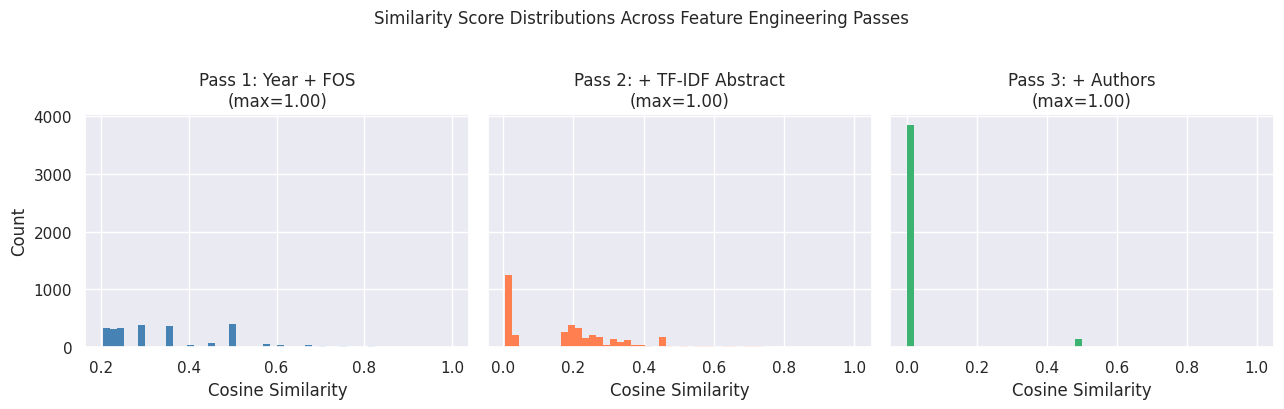

In [ ]:
# Compare similarity distributions across passes
test_ix = model_df.index.get_loc(test_paper)

sim_pass1 = cosine_similarity(second_features[test_ix:test_ix+1],
                               second_features).flatten()
sim_pass2 = cosine_similarity(third_features[test_ix:test_ix+1],
                               third_features).flatten()
sim_pass3 = cosine_similarity(fourth_features[test_ix:test_ix+1],
                               fourth_features).flatten()

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

axes[0].hist(sim_pass1[sim_pass1 > 0], bins=50, color='steelblue', edgecolor='none')
axes[0].set_title(f'Pass 1: Year + FOS\n(max={sim_pass1.max():.2f})')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Count')

axes[1].hist(sim_pass2[sim_pass2 > 0], bins=50, color='coral', edgecolor='none')
axes[1].set_title(f'Pass 2: + TF-IDF Abstract\n(max={sim_pass2.max():.2f})')
axes[1].set_xlabel('Cosine Similarity')

axes[2].hist(sim_pass3[sim_pass3 > 0], bins=50, color='mediumseagreen', edgecolor='none')
axes[2].set_title(f'Pass 3: + Authors\n(max={sim_pass3.max():.2f})')
axes[2].set_xlabel('Cosine Similarity')

plt.suptitle('Similarity Score Distributions Across Feature Engineering Passes',
             fontsize=12, y=1.02)
plt.tight_layout()

**Figure: How feature engineering changes the similarity landscape.** Each histogram shows the distribution of cosine similarity scores between a target paper and all other papers.

- **Pass 1** (Year + FOS): Many papers have identical high scores -- the features are too coarse to discriminate. This creates a "pile-up" at the top, making it hard to rank recommendations.
- **Pass 2** (+ TF-IDF): The distribution spreads out, with fewer ties. TF-IDF introduces fine-grained vocabulary differences that break ties between papers in the same field.
- **Pass 3** (+ Authors): Further refinement, especially boosting similarity for papers by the same author or institution.

The progression demonstrates the central lesson of this chapter: **more informative features produce more discriminating similarity scores**, which in turn produce better recommendations.

## Performance Summary: The Power of Feature Engineering

In [ ]:
# Summary table
print("=" * 70)
print(f"{'Pass':>8s} | {'Features':>10s} | {'Memory (MB)':>12s} | {'Query Time':>12s}")
print("=" * 70)

# Measure query times
import time

for name, feats in [('Pass 1', second_features),
                     ('Pass 2', third_features),
                     ('Pass 3', fourth_features)]:
    start = time.time()
    for _ in range(10):
        piped_collab_filter(feats, 0, 5)
    elapsed = (time.time() - start) / 10
    mem = getsizeof(feats) / 1e6
    print(f"{name:>8s} | {feats.shape[1]:>10,} | {mem:>10.1f}  | {elapsed*1000:>9.1f} ms")
print("=" * 70)

    Pass |   Features |  Memory (MB) |   Query Time
  Pass 1 |         65 |        2.6  |       3.6 ms
  Pass 2 |        248 |        9.9  |      10.1 ms
  Pass 3 |      1,002 |       40.1  |      45.9 ms


The query time scales with the number of features -- more features means more computation per similarity score. However, the per-query time remains in the milliseconds range, well within acceptable limits for interactive use. The critical speedup came from replacing the $O(n^2)$ nested loop with the $O(n)$ vectorized single-item query.

## Appendix: Index Management Between Pandas and NumPy

Converting between Pandas DataFrames and NumPy arrays can make index tracking tricky. The three key methods:

In [ ]:
# Example 9-11: Index management
print("Pandas .loc (original DataFrame index):")
print(f"  model_df.loc[21]['title'] = '{model_df.loc[21]['title']}'")
print(f"  model_df.loc[21]['year']  = {model_df.loc[21]['year']}")

print(f"\nPandas .iloc (integer position):")
print(f"  model_df.iloc[21]['title'] = '{model_df.iloc[21]['title']}'")
print(f"  model_df.iloc[21]['year']  = {model_df.iloc[21]['year']}")

print(f"\nTranslation: model_df.index.get_loc(21) = {model_df.index.get_loc(21)}")
print(f"  (In this case they match because our index is 0-based contiguous)")

Pandas .loc (original DataFrame index):
  model_df.loc[21]['title'] = 'Based embedding problem novel translation word parsing'
  model_df.loc[21]['year']  = 2017

Pandas .iloc (integer position):
  model_df.iloc[21]['title'] = 'Based embedding problem novel translation word parsing'
  model_df.iloc[21]['year']  = 2017

Translation: model_df.index.get_loc(21) = 21
  (In this case they match because our index is 0-based contiguous)


When the DataFrame index is not contiguous (e.g., after filtering or dropping rows), `.loc` and `.iloc` can return *different* rows. The NumPy array always uses integer positions (like `.iloc`). The `.get_loc()` method bridges the two, finding the integer position for a given DataFrame index value. This is critical for correctly mapping between similarity matrix indices and paper identifiers.

---
# Chapter Summary

We built an academic paper recommender through three iterative passes, each demonstrating key feature engineering principles:

| Pass | Features | Technique | Key Lesson |
|---|---|---|---|
| **1** | Year + FOS (raw) | Binary encoding, nested loops | Brute force is slow; raw features create sparse, memory-hungry matrices |
| **2** | Year (binned) + FOS (sparse) | Fixed-width binning, NumPy arrays, vectorized cosine | Binning compresses features; NumPy arrays save orders of magnitude in memory; vectorized ops are 100x+ faster |
| **3** | + Abstract (tf-idf) + Authors (one-hot) | TF-IDF, DictVectorizer, sparse matrices | Text features provide fine-grained discrimination; more features = better recommendations |

**Key takeaways:**

1. **Raw data is never model-ready.** Lists, dictionaries, free text, and mixed types all require transformation before any algorithm can use them.

2. **Feature engineering is iterative.** We did not know in advance which features would work. Each pass taught us something: year alone is too coarse, fos has too many NaNs, abstracts provide the richest signal.

3. **Computational efficiency matters.** A 2.5 GB DataFrame and an $O(n^2)$ loop would make iteration impossible. Sparse representations and vectorized computation enabled rapid experimentation.

4. **More data does not fix bad features.** As the textbook notes, "even Big Data cannot compensate for poor data and engineering choices." The improvement from Pass 1 to Pass 3 came from *better features*, not more data.

5. **"Best" is subjective.** A recommender's quality ultimately depends on what users find helpful -- which may not be directly represented in the data. Feature engineering bridges the gap between raw data and user intent.

The iterative cycle of *hypothesize $\to$ engineer features $\to$ evaluate $\to$ refine* is the essence of practical machine learning. Mastery comes not from memorizing techniques, but from developing the intuition to know which technique to apply, when, and why.